# Zarr files

Zarr files provide an efficient way to store datasets in replacement to working with multiple NetCDF files. They can make data analysis faster and are well suited for sharing datasets and working with cloud-based platforms.

---

## What is a zarr file?

A Zarr dataset is stored as a directory rather than as a single file. As shown below, the different arrays in the dataset are organized into separate subdirectories, and the data within each array is divided into smaller chunks. This chunked structure is one of the main advantages of Zarr, as it allows data to be accessed in smaller portions rather than reading the entire array at once. When saving to zarr, you can customize the chunk sizes to fit your usage rather than relying on existing binary or NetCDF file structures.

```{image} zarr_structure.png
:alt: Zarr structure
:width: 500px
:align: center
```

When a Zarr dataset is opened, the data is automatically loaded lazily with a Dask computation graph (see **[Lazy loading & chunking](lazy-loading.ipynb)** to learn more about lazy loading and Dask, although by nature, a zarr file is necessarily loaded lazily and nothing needs to be turned on). 

## Saving to Zarr

Xarray provides a convenient interface for working with Zarr datasets, allowing you to easily open, inspect, and manipulate the data without having to interact directly with the underlying Zarr structure. For more details on using zarr with xarray see **[Introduction to Zarr](https://tutorial.xarray.dev/intermediate/intro-to-zarr.html)**.

In [2]:
import xarray as xr
import xhycom

Set the paths below to point at your data before running.

In [5]:
GRID_PATH = "/cluster/home/arnelt/NERSC-HYCOM-CICE/TP2a0.10/topo/regional.grid"
DATA_PATH = "/cluster/work/users/arnelt/TP2a0.10/expt_93.5/data/"

In [6]:
ds = xhycom.open_mfdataset(DATA_PATH + "archm.*", grid=GRID_PATH, chunks={"time": 1}, postprocess=True)

Alternatively, you can load NetCDF files with xarray instead of the Hycom output.

Any postprocessing can be applied to the data before saving. For example you can regrid it with xhycom utilities (see **[Regridding](regridding.ipynb)**).

Xarray's `to_zarr` handles saving any dataset to a zarr file at the desired location. For large datasets, this task should be submitted to a slurm job.

In [ ]:
ds.to_zarr("output.zarr", mode="w")

`mode=` lets you choose how an existing Zarr store is handled :

- `mode="w"`: overwrite the existing Zarr store.
- `mode="w-"`: create a new store and raise an error if it already exists.
- `mode="a"`: append to or update an existing Zarr store.
- `mode="a-"`: append new variables without overwriting existing ones.
- `mode="r+"`: modify existing data without changing the store's metadata.

Chunking is handled automatically by `to_zarr`. To change it, rechunk the dataset before saving it with `ds.chunk`.

The optional argument `group=` lets you create groups inside of your dataset. This is useful for example if you want to save both daily and monthly variables in the same Zarr file. The example below shows how to extract variables, compute monthly means and save them. With the lazy data, the computation is only done when writing the Zarr file.

In [ ]:
ds_daily = ds[["temp", "salin"]]
ds_monthly = ds[["temp", "salin"]].resample(time="1MS").mean()

In [ ]:
ds_daily.to_zarr("output.zarr", group="daily", mode="w")
ds_monthly.to_zarr("output.zarr", group="monthly", mode="a")

The first dataset uses the write mode `mode=w` to create the archive, while the second one uses `mode=a` to append a group to the existing Zarr file.

Groups work like paths which means that you can create subgroups with `group="group/subgroup"`.

## Opening a Zarr file

Any Zarr file can be opened using xarray with `open_zarr`.

In [7]:
zds = xr.open_zarr("/cluster/work/users/arnelt/test2.zarr")

This lazily loads the Zarr file as an xarray dataset. The argument `group=` lets you choose which group to open if multiple are present.

In [8]:
zds

<xarray.Dataset> Size: 6TB
Dimensions:     (time: 1887, k: 50, y: 380, x: 400, ki: 51)
Coordinates:
  * time        (time) datetime64[ns] 15kB 1993-11-01 1993-11-02 ... 1998-12-31
  * k           (k) int64 400B 1 2 3 4 5 6 7 8 9 ... 42 43 44 45 46 47 48 49 50
    dens        (k) float64 400B dask.array<chunksize=(50,), meta=np.ndarray>
    lat         (y, x) float64 1MB dask.array<chunksize=(380, 400), meta=np.ndarray>
    lat_u       (y, x) float64 1MB dask.array<chunksize=(380, 400), meta=np.ndarray>
    lat_v       (y, x) float64 1MB dask.array<chunksize=(380, 400), meta=np.ndarray>
    lon         (y, x) float64 1MB dask.array<chunksize=(380, 400), meta=np.ndarray>
    lon_u       (y, x) float64 1MB dask.array<chunksize=(380, 400), meta=np.ndarray>
    lon_v       (y, x) float64 1MB dask.array<chunksize=(380, 400), meta=np.ndarray>
  * ki          (ki) int64 408B 0 1 2 3 4 5 6 7 8 ... 42 43 44 45 46 47 48 49 50
Dimensions without coordinates: y, x
Data variables: (12/82)
    attenuat    (time, k, y, x) float64 115GB dask.array<chunksize=(1, 50, 380, 400), meta=np.ndarray>
    bl_dpth     (time, y, x) float64 2GB dask.array<chunksize=(1, 380, 400), meta=np.ndarray>
    CO2_BiCa    (time, k, y, x) float64 115GB dask.array<chunksize=(1, 50, 380, 400), meta=np.ndarray>
    CO2_c       (time, k, y, x) float64 115GB dask.array<chunksize=(1, 50, 380, 400), meta=np.ndarray>
    CO2_Carb_1  (time, k, y, x) float64 115GB dask.array<chunksize=(1, 50, 380, 400), meta=np.ndarray>
    CO2_Carb_2  (time, k, y, x) float64 115GB dask.array<chunksize=(1, 50, 380, 400), meta=np.ndarray>
    ...          ...
    u_btrop     (time, y, x) float64 2GB dask.array<chunksize=(1, 380, 400), meta=np.ndarray>
    umix        (time, y, x) float64 2GB dask.array<chunksize=(1, 380, 400), meta=np.ndarray>
    v-vel.      (time, k, y, x) float64 115GB dask.array<chunksize=(1, 50, 380, 400), meta=np.ndarray>
    v_btrop     (time, y, x) float64 2GB dask.array<chunksize=(1, 380, 400), meta=np.ndarray>
    vmix        (time, y, x) float64 2GB dask.array<chunksize=(1, 380, 400), meta=np.ndarray>
    wtrflx      (time, y, x) float64 2GB dask.array<chunksize=(1, 380, 400), meta=np.ndarray>
Attributes:
    iversn:        23
    iexpt:         931
    yrflag:        3
    archive_type:  mean

## Comparing performances

In this section, we show the increase in performance of reading and working with data stored in a Zarr archive instead of the original HYCOM binary output files using xhycom. 

A 64 months NERSC-HYCOM-CICE run is used for this comparison. The Zarr file showed great compression capabilities, along side its speed, as it reduced the 2.8T of space used by the binary files to 755G (73.2% reduction).

Zarr was also compared to the equivalent data stored in NetCDF files. The results showed a similar speed-up when using Zarr instead of both the original HYCOM binary files and the NetCDF files.

In [9]:
%time ds = xhycom.open_mfdataset(DATA_PATH + "archm.*", grid=GRID_PATH, chunks={"time": 1}, postprocess=True)

CPU times: user 1min 15s, sys: 5.13 s, total: 1min 21s
Wall time: 1min 37s


In [10]:
%time zds = xr.open_zarr("/cluster/work/users/arnelt/test2.zarr")

CPU times: user 69.7 ms, sys: 16 ms, total: 85.7 ms
Wall time: 2.33 s


Zarr files have the advantage of opening instantly because of their structure (only metadata needs to be read) whereas other file types require finding all files and constructing the dask graph.

The resulting dataset is exactly the same.

In [11]:
ds

<xarray.Dataset> Size: 6TB
Dimensions:     (y: 380, x: 400, time: 1887, k: 50, ki: 51)
Coordinates:
    lon         (y, x) float64 1MB dask.array<chunksize=(380, 400), meta=np.ndarray>
    lat         (y, x) float64 1MB dask.array<chunksize=(380, 400), meta=np.ndarray>
    lon_u       (y, x) float64 1MB dask.array<chunksize=(380, 400), meta=np.ndarray>
    lat_u       (y, x) float64 1MB dask.array<chunksize=(380, 400), meta=np.ndarray>
    lon_v       (y, x) float64 1MB dask.array<chunksize=(380, 400), meta=np.ndarray>
    lat_v       (y, x) float64 1MB dask.array<chunksize=(380, 400), meta=np.ndarray>
  * time        (time) object 15kB 1993-11-01 00:00:00 ... 1998-12-31 00:00:00
  * k           (k) int64 400B 1 2 3 4 5 6 7 8 9 ... 42 43 44 45 46 47 48 49 50
    dens        (k) float64 400B dask.array<chunksize=(50,), meta=np.ndarray>
  * ki          (ki) int64 408B 0 1 2 3 4 5 6 7 8 ... 42 43 44 45 46 47 48 49 50
Dimensions without coordinates: y, x
Data variables: (12/82)
    montg1      (time, y, x) float64 2GB dask.array<chunksize=(1, 380, 400), meta=np.ndarray>
    srfhgt      (time, y, x) float64 2GB dask.array<chunksize=(1, 380, 400), meta=np.ndarray>
    oneta       (time, y, x) float64 2GB dask.array<chunksize=(1, 380, 400), meta=np.ndarray>
    surflx      (time, y, x) float64 2GB dask.array<chunksize=(1, 380, 400), meta=np.ndarray>
    wtrflx      (time, y, x) float64 2GB dask.array<chunksize=(1, 380, 400), meta=np.ndarray>
    salflx      (time, y, x) float64 2GB dask.array<chunksize=(1, 380, 400), meta=np.ndarray>
    ...          ...
    ECO_sed3    (time, y, x) float64 2GB dask.array<chunksize=(1, 380, 400), meta=np.ndarray>
    CO2_fair    (time, y, x) float64 2GB dask.array<chunksize=(1, 380, 400), meta=np.ndarray>
    CO2_wind    (time, y, x) float64 2GB dask.array<chunksize=(1, 380, 400), meta=np.ndarray>
    ECO_bots    (time, y, x) float64 2GB dask.array<chunksize=(1, 380, 400), meta=np.ndarray>
    si_u        (time, y, x) float64 2GB dask.array<chunksize=(1, 380, 400), meta=np.ndarray>
    si_v        (time, y, x) float64 2GB dask.array<chunksize=(1, 380, 400), meta=np.ndarray>
Attributes:
    iversn:        23
    iexpt:         931
    yrflag:        3
    archive_type:  mean

In [12]:
zds

<xarray.Dataset> Size: 6TB
Dimensions:     (time: 1887, k: 50, y: 380, x: 400, ki: 51)
Coordinates:
  * time        (time) datetime64[ns] 15kB 1993-11-01 1993-11-02 ... 1998-12-31
  * k           (k) int64 400B 1 2 3 4 5 6 7 8 9 ... 42 43 44 45 46 47 48 49 50
    dens        (k) float64 400B dask.array<chunksize=(50,), meta=np.ndarray>
    lat         (y, x) float64 1MB dask.array<chunksize=(380, 400), meta=np.ndarray>
    lat_u       (y, x) float64 1MB dask.array<chunksize=(380, 400), meta=np.ndarray>
    lat_v       (y, x) float64 1MB dask.array<chunksize=(380, 400), meta=np.ndarray>
    lon         (y, x) float64 1MB dask.array<chunksize=(380, 400), meta=np.ndarray>
    lon_u       (y, x) float64 1MB dask.array<chunksize=(380, 400), meta=np.ndarray>
    lon_v       (y, x) float64 1MB dask.array<chunksize=(380, 400), meta=np.ndarray>
  * ki          (ki) int64 408B 0 1 2 3 4 5 6 7 8 ... 42 43 44 45 46 47 48 49 50
Dimensions without coordinates: y, x
Data variables: (12/82)
    attenuat    (time, k, y, x) float64 115GB dask.array<chunksize=(1, 50, 380, 400), meta=np.ndarray>
    bl_dpth     (time, y, x) float64 2GB dask.array<chunksize=(1, 380, 400), meta=np.ndarray>
    CO2_BiCa    (time, k, y, x) float64 115GB dask.array<chunksize=(1, 50, 380, 400), meta=np.ndarray>
    CO2_c       (time, k, y, x) float64 115GB dask.array<chunksize=(1, 50, 380, 400), meta=np.ndarray>
    CO2_Carb_1  (time, k, y, x) float64 115GB dask.array<chunksize=(1, 50, 380, 400), meta=np.ndarray>
    CO2_Carb_2  (time, k, y, x) float64 115GB dask.array<chunksize=(1, 50, 380, 400), meta=np.ndarray>
    ...          ...
    u_btrop     (time, y, x) float64 2GB dask.array<chunksize=(1, 380, 400), meta=np.ndarray>
    umix        (time, y, x) float64 2GB dask.array<chunksize=(1, 380, 400), meta=np.ndarray>
    v-vel.      (time, k, y, x) float64 115GB dask.array<chunksize=(1, 50, 380, 400), meta=np.ndarray>
    v_btrop     (time, y, x) float64 2GB dask.array<chunksize=(1, 380, 400), meta=np.ndarray>
    vmix        (time, y, x) float64 2GB dask.array<chunksize=(1, 380, 400), meta=np.ndarray>
    wtrflx      (time, y, x) float64 2GB dask.array<chunksize=(1, 380, 400), meta=np.ndarray>
Attributes:
    iversn:        23
    iexpt:         931
    yrflag:        3
    archive_type:  mean

Plotting maps and time series show a huge speed-up with Zarr files.

CPU times: user 1.54 s, sys: 99.9 ms, total: 1.64 s
Wall time: 3.11 s


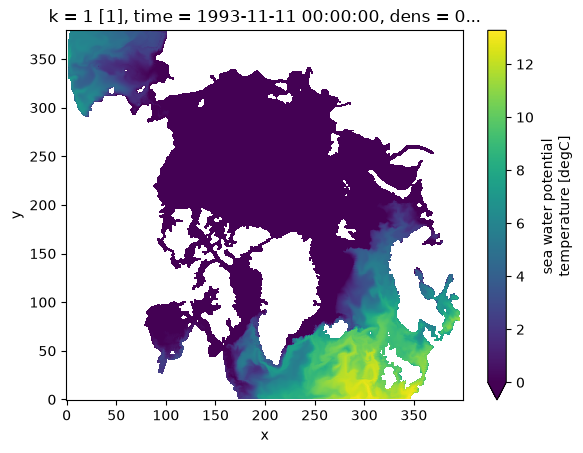

In [28]:
sst = ds["temp"].isel(time=10, k=0)
%time sst.plot(vmin=0)

CPU times: user 103 ms, sys: 18.7 ms, total: 122 ms
Wall time: 202 ms


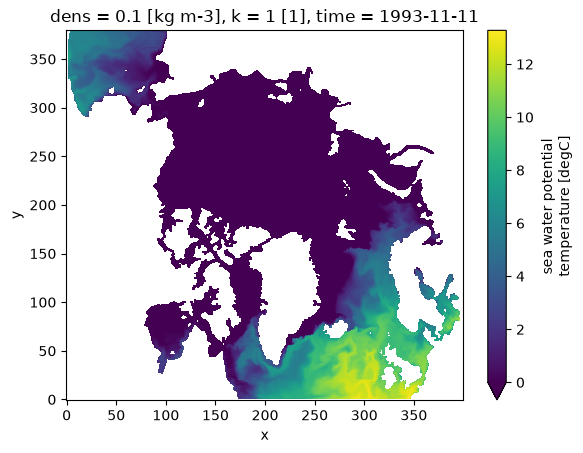

In [29]:
sst = zds["temp"].isel(time=10, k=0)
%time sst.plot(vmin=0)

CPU times: user 3min 3s, sys: 7min 5s, total: 10min 8s
Wall time: 3min 43s


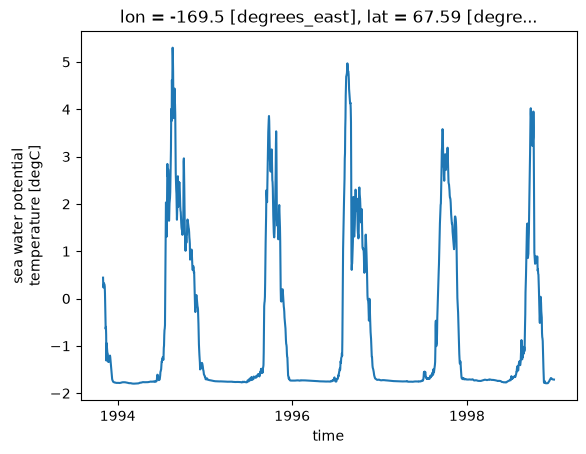

In [26]:
sst = ds["temp"].isel(y=300, x=100, k=0)
%time sst.plot()

CPU times: user 1min 42s, sys: 40.9 s, total: 2min 23s
Wall time: 34.8 s


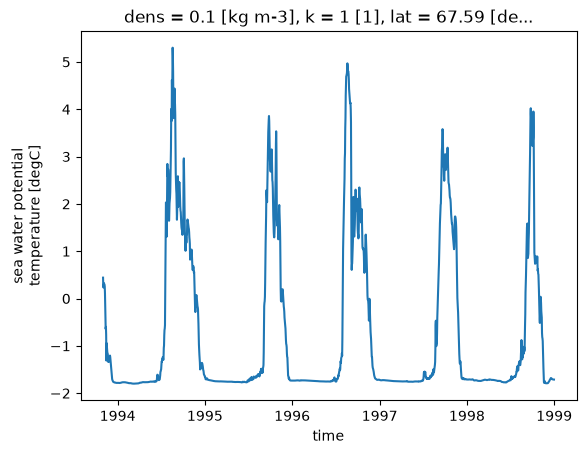

In [27]:
sst = zds["temp"].isel(y=300, x=100, k=0)
%time sst.plot()

Note that with the chunk size of 1 along time on both datasets, plotting a map is particularly fast compared to plotting time series. Different chunking of the Zarr file can greatly improve time series plotting.